<h2> Nauczanie maszynowe/Ćwiczenia3

* 27.10.2025 Jadwiga Krząstek

<h2> Optymalizatory

In [1]:
import torch
from utils import visualize_optimizer
from checker import test_optimizer

C:\Users\jadwi\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\utils\generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [3]:
from typing import List

class Optimizer:
    """Klasa bazowa dla optymalizatorów"""
    
    def __init__(self, initial_params):
        # store model weights
        self.params = initial_params
    
    def step(self):
        """w self.params będą aktualizacje wag"""
        raise NotImplementedError()
         
    def zero_grad(self):
        """Torch akumuluje gradient, więc go zerujemy po kazdej aktualizacji"""
        for param in self.params:
            if param.grad is not None:
                param.grad.detach_()
                param.grad.zero_()

<h4> Zadanie1: Uzupełnij definicję poniżej klasy: MOMENTUM

In [5]:
class Momentum(Optimizer):
    
    def __init__(self, initial_params, learning_rate, gamma):
        super().__init__(initial_params)
        
        self.learning_rate = learning_rate
        self.gamma = gamma
        
        self.deltas = [] #lista tensorów
        
        for param in self.params:
            self.deltas.append(torch.zeros_like(param))
              
    @torch.no_grad()
    def step(self):
        for i, param in enumerate(self.params):
            self.deltas[i] = self.gamma * self.deltas[i] + self.learning_rate * param.grad
            param -= self.deltas[i]

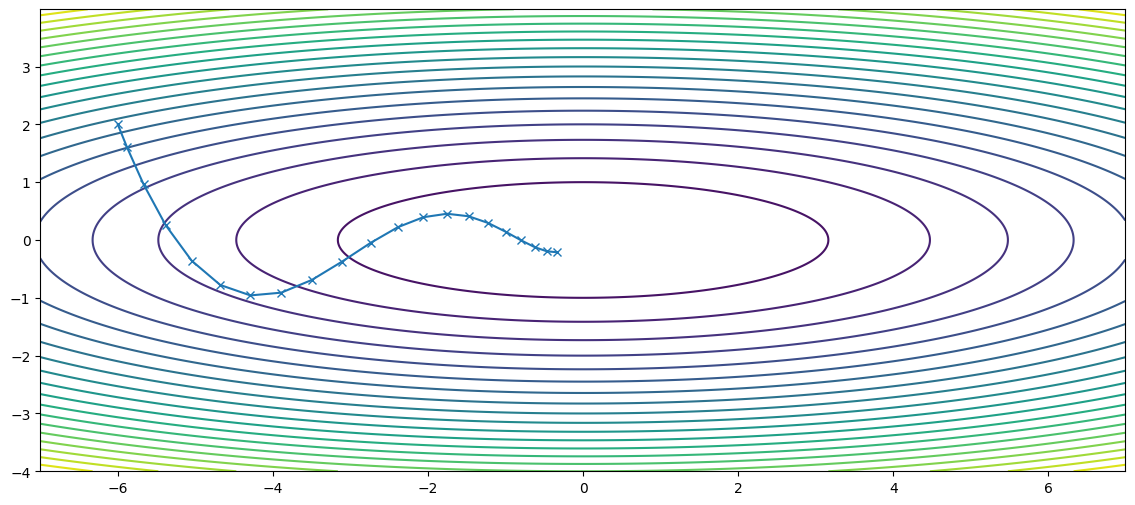

In [13]:
visualize_optimizer(Momentum, n_steps=20, learning_rate=0.05, gamma=0.8)

<h4> Zadanie2: Uzupełnij definicję poniżej klasy: ADAGRAD

In [6]:
class Adagrad(Optimizer):
    
    def __init__(self, initial_params, learning_rate, epsilon):
        super().__init__(initial_params)
        self.learning_rate = learning_rate
        self.epsilon = epsilon
        
        self.G = []
        for param in self.params:
            self.G.append(torch.zeros_like(param))
                    
    @torch.no_grad()
    def step(self):
        for i, param in enumerate(self.params):
            self.G[i] += param.grad ** 2                       
            param -= self.learning_rate / (torch.sqrt(self.G[i]) + self.epsilon) * param.grad


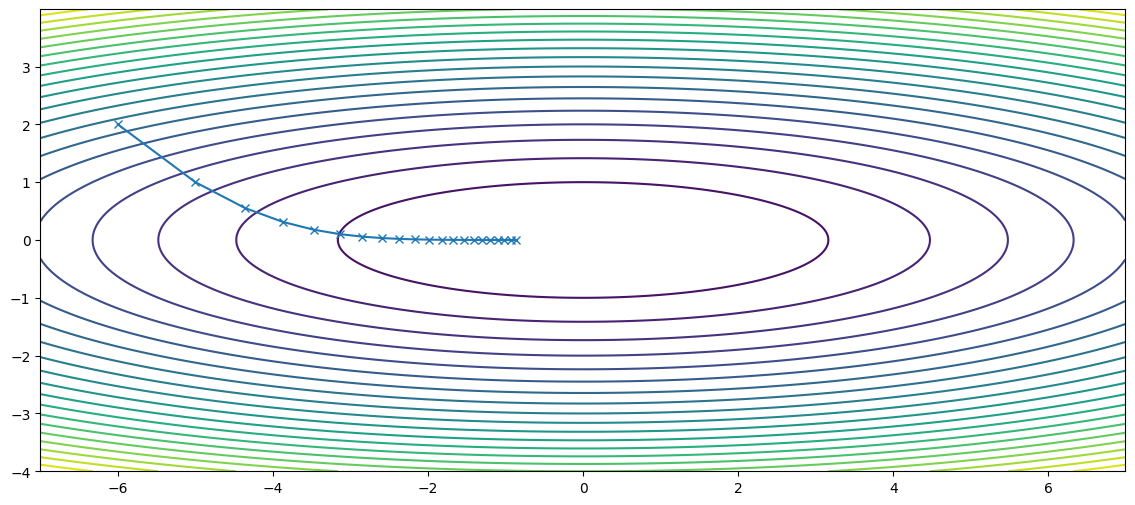

In [30]:
visualize_optimizer(Adagrad, n_steps=20, learning_rate=1.0, epsilon=1e-8)

<h4> Zadanie3: Uzupełnij definicję poniżej klasy: RMSProp

In [7]:
class RMSProp(Optimizer):
    
    def __init__(self, initial_params, learning_rate, gamma, epsilon):
        super().__init__(initial_params)
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon
        
        self.H = []
        for param in self.params:
            self.H.append(torch.zeros_like(param))
        
    @torch.no_grad()
    def step(self):
        for i, param in enumerate(self.params):
            self.H[i] = self.gamma * self.H[i] + (1 - self.gamma) * param.grad * param.grad
            param -= self.learning_rate / (torch.sqrt(self.H[i] + self.epsilon)) * param.grad

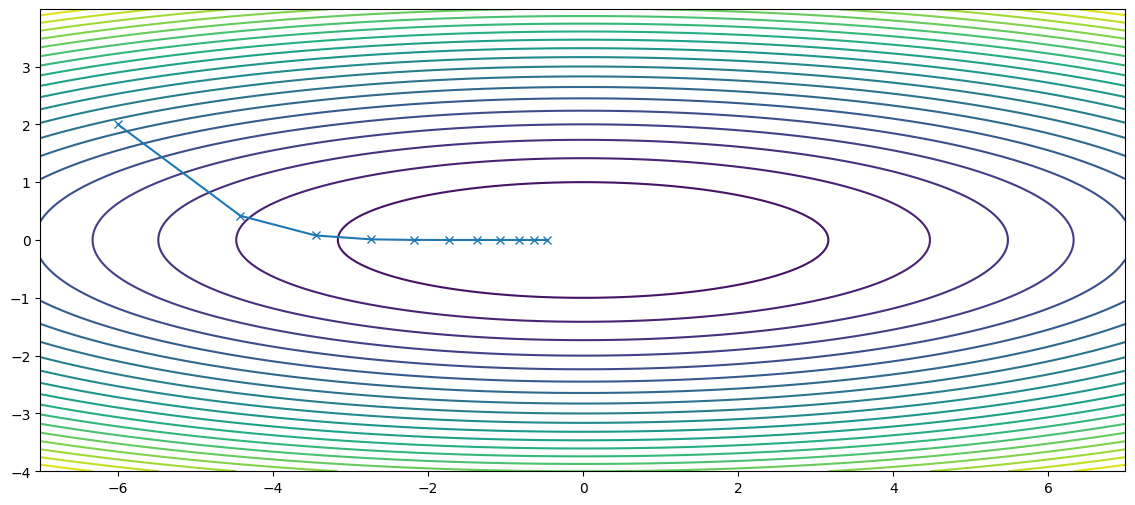

In [40]:
visualize_optimizer(RMSProp, n_steps=10, learning_rate=0.5, gamma=0.9, epsilon=1e-8)

<h4> Zadanie4: Uzupełnij definicję poniżej klasy: ADADELTA

In [27]:
class Adadelta(Optimizer):
    def __init__(self, initial_params, gamma, epsilon):
        super().__init__(initial_params)
        self.gamma = gamma
        self.epsilon = epsilon

        self.H = []
        self.D = []
        for param in self.params:
            self.H.append(torch.zeros_like(param))

        for param in self.params:
            self.D.append(torch.zeros_like(param))
        
    @torch.no_grad()
    def step(self):
        for i, param in enumerate(self.params):
            self.H[i] = self.gamma * self.H[i] + (1 - self.gamma) * param.grad * param.grad
            delta = torch.sqrt(self.D[i] + self.epsilon) / torch.sqrt(self.H[i] + self.epsilon) * param.grad
            param -= delta
            self.D[i] = self.gamma * self.D[i] + (1 - self.gamma) * delta * delta

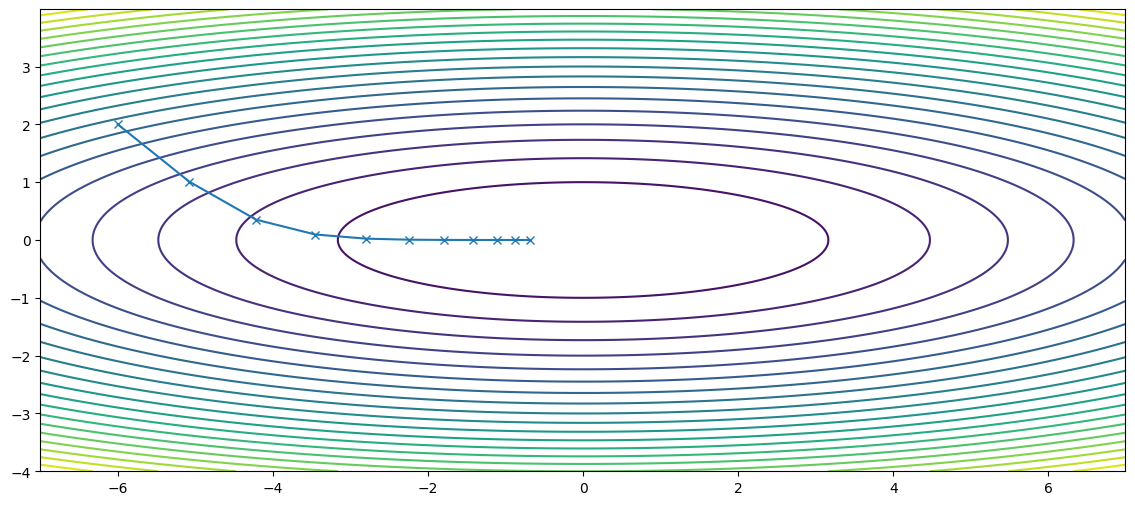

In [29]:
visualize_optimizer(Adadelta, n_steps=10, gamma=0.9, epsilon=1e-1)

<h4> Zadanie5: Uzupełnij definicję poniżej klasy: ADAM

In [46]:
class Adam(Optimizer):
   
    def __init__(self, initial_params, learning_rate, beta1, beta2, epsilon):
        super().__init__(initial_params)
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        
        self.m = []
        self.v = []
        for param in self.params:
            self.m.append(torch.zeros_like(param))
        for param in self.params:
            self.v.append(torch.zeros_like(param))
        self.t = 0
        
    @torch.no_grad()
    def step(self,):
        self.t += 1
        for i, param in enumerate(self.params):
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * param.grad
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * param.grad * param.grad
            m_p = self.m[i] / (1 - self.beta1 ** self.t)
            v_p = self.v[i] / (1 - self.beta2 ** self.t)
            param -= self.learning_rate * m_p / (torch.sqrt(v_p) + self.epsilon)     

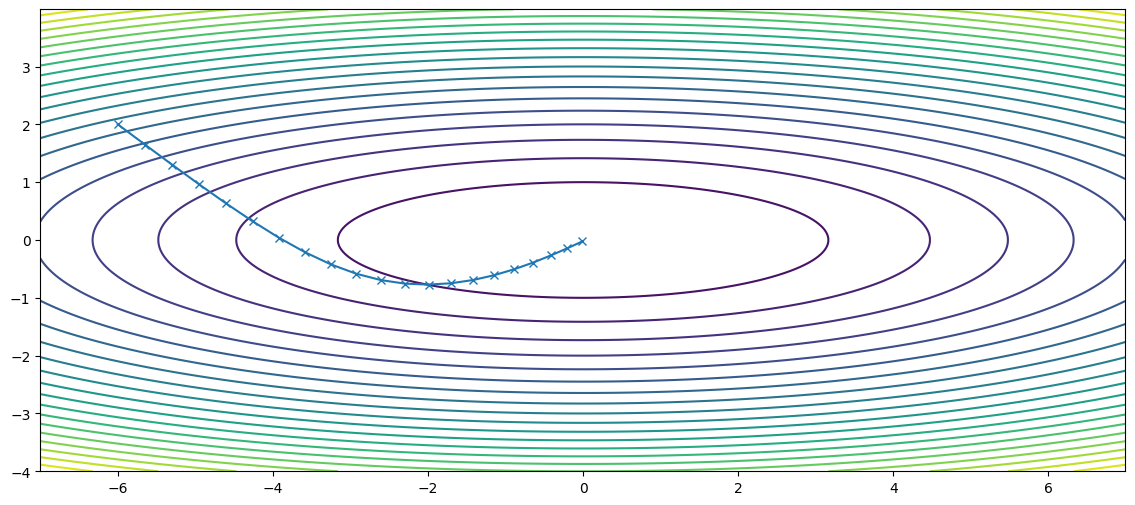

In [47]:
visualize_optimizer(Adam, n_steps=20, learning_rate=0.35, beta1=0.9, beta2=0.999, epsilon=1e-8)